In [34]:
# Cell 1: Setup
!pip install kagglehub -q
import kagglehub
import pandas as pd
import os

In [35]:
# Cell 2: Download and Loading Dataset
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")
print(f"Dataset downloaded to: {path}")

# Load the CSV file
df = pd.read_csv(os.path.join(path, "Housing.csv"))
print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns")

# Show first few rows
print("\nFirst 5 rows:")
print(df.head())

Using Colab cache for faster access to the 'housing-prices-dataset' dataset.
Dataset downloaded to: /kaggle/input/housing-prices-dataset
Loaded 545 rows and 13 columns

First 5 rows:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes       

In [36]:
# Cell 3: Task 1 - Data Exploration

print("="*60)
print(" TASK 1: DATA EXPLORATION")
print("="*60)

# 1. Display first 10 rows
print("\n First 10 rows:")
print(df.head(10))

# 2. Check rows and columns
print(f"\n Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

# 3. Identify target and features
target = 'price'
features = [col for col in df.columns if col != target]
print(f"\n Target Variable: {target}")
print(f" Feature Variables: {features}")

# 4. Check missing values
print("\n Missing Values in each column:")
print(df.isnull().sum())

# 5. Data types
print("\n Data Types:")
print(df.dtypes)

# 6. Statistical summary
print("\n Statistical Summary:")
print(df.describe())

 TASK 1: DATA EXPLORATION

 First 10 rows:
      price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000   7420         4          2        3      yes        no       no   
1  12250000   8960         4          4        4      yes        no       no   
2  12250000   9960         3          2        2      yes        no      yes   
3  12215000   7500         4          2        2      yes        no      yes   
4  11410000   7420         4          1        2      yes       yes      yes   
5  10850000   7500         3          3        1      yes        no      yes   
6  10150000   8580         4          3        4      yes        no       no   
7  10150000  16200         5          3        2      yes        no       no   
8   9870000   8100         4          1        2      yes       yes      yes   
9   9800000   5750         3          2        4      yes       yes       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0    

In [37]:
# Cell 4: Task 2 - Data Cleaning

print("="*60)
print("TASK 2: DATA CLEANING")
print("="*60)

# 2.1 Check for missing values (already confirmed)
print("\n No missing values to handle")

# 2.2 Removing duplicate rows
duplicates = df.duplicated().sum()
print(f"\n Duplicate rows found: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"   Removed {duplicates} duplicates")
else:
    print("   No duplicates to remove")

# 2.3 Converting categorical columns to numeric (One-Hot Encoding)
categorical_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
                   'airconditioning', 'prefarea', 'furnishingstatus']

print(f"\n Converting {len(categorical_cols)} categorical columns...")
print(f"   Columns: {categorical_cols}")

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"\n After encoding: {df_encoded.shape[0]} rows, {df_encoded.shape[1]} columns")

# 2.4 Features
print("\nAdding engineered features...")
df_encoded['area_per_room'] = df_encoded['area'] / (df_encoded['bedrooms'] + 1)
df_encoded['price_per_sqft'] = df_encoded['price'] / df_encoded['area']

print(f" Added: area_per_room, price_per_sqft")
print(f" Final dataset shape: {df_encoded.shape[0]} rows, {df_encoded.shape[1]} columns")

# The new columns
print("\n All columns now:")
print(df_encoded.columns.tolist())

# Previewing the encoded data
print("\nFirst 5 rows of encoded data:")
print(df_encoded.head())

TASK 2: DATA CLEANING

 No missing values to handle

 Duplicate rows found: 0
   No duplicates to remove

 Converting 7 categorical columns...
   Columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

 After encoding: 545 rows, 14 columns

Adding engineered features...
 Added: area_per_room, price_per_sqft
 Final dataset shape: 545 rows, 16 columns

 All columns now:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished', 'area_per_room', 'price_per_sqft']

First 5 rows of encoded data:
      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2          True   
1  12250000  8960         4          4        4        3          True   
2  12250000  9960         3         

In [38]:
# Cell 5: Task 3 - Model Building

print("="*60)
print("TASK 3: MODEL BUILDING & EVALUATION")
print("="*60)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 3.1 Prepare data
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

print(f"\nFeatures: {X.shape[1]} columns")
print(f"Target: price")

# 3.2 Split data (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set: {len(X_train)} samples (80%)")
print(f"Test set: {len(X_test)} samples (20%)")

# 3.3 Scale features (for Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled")

# 3.4 Train Linear Regression
print("\n Training Linear Regression...")
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print(f"\nLinear Regression Results:")
print(f"   MAE: ${lr_mae:,.2f}")
print(f"   RMSE: ${lr_rmse:,.2f}")
print(f"   R² Score: {lr_r2:.4f}")

# 3.5 Train Random Forest
print("\nTraining Random Forest...")
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print(f"\nRandom Forest Results:")
print(f"   MAE: ${rf_mae:,.2f}")
print(f"   RMSE: ${rf_rmse:,.2f}")
print(f"   R² Score: {rf_r2:.4f}")

# 3.6 Compare models
print("\nModel Comparison:")
print("-" * 50)
print(f"{'Metric':<15} {'Linear Regression':<20} {'Random Forest':<20}")
print("-" * 50)
print(f"{'MAE':<15} ${lr_mae:>15,.2f}   ${rf_mae:>15,.2f}")
print(f"{'RMSE':<15} ${lr_rmse:>15,.2f}   ${rf_rmse:>15,.2f}")
print(f"{'R² Score':<15} {lr_r2:>15.4f}     {rf_r2:>15.4f}")
print("-" * 50)

# Determine best model
if rf_r2 > lr_r2:
    best_model = "Random Forest"
    best_r2 = rf_r2
    best_mae = rf_mae
else:
    best_model = "Linear Regression"
    best_r2 = lr_r2
    best_mae = lr_mae

print(f"\nBest Model: {best_model} (R² = {best_r2:.4f})")

TASK 3: MODEL BUILDING & EVALUATION

Features: 15 columns
Target: price

Training set: 436 samples (80%)
Test set: 109 samples (20%)

Features scaled

 Training Linear Regression...

Linear Regression Results:
   MAE: $497,560.63
   RMSE: $756,632.22
   R² Score: 0.8867

Training Random Forest...

Random Forest Results:
   MAE: $289,233.34
   RMSE: $578,141.76
   R² Score: 0.9339

Model Comparison:
--------------------------------------------------
Metric          Linear Regression    Random Forest       
--------------------------------------------------
MAE             $     497,560.63   $     289,233.34
RMSE            $     756,632.22   $     578,141.76
R² Score                 0.8867              0.9339
--------------------------------------------------

Best Model: Random Forest (R² = 0.9339)


TASK 4: VISUALIZATION

Creating Chart 1: Price Distribution


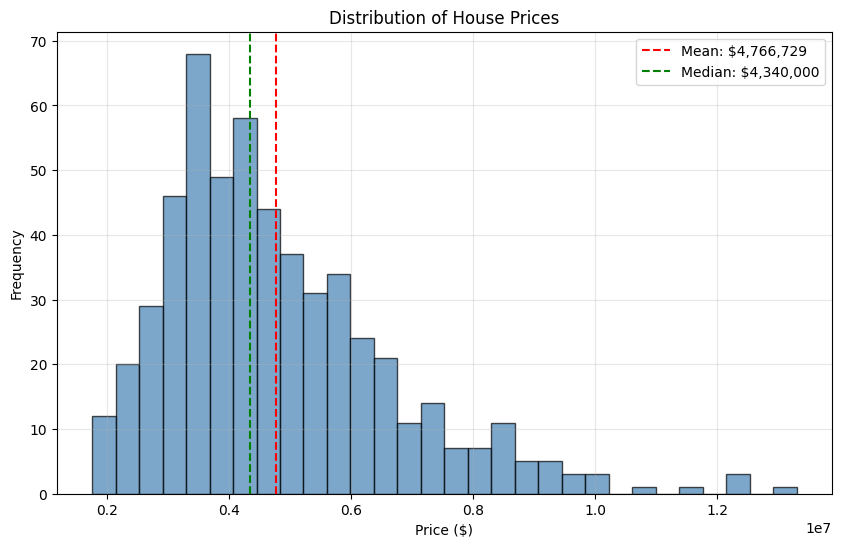


Creating Chart 2: Correlation Heatmap


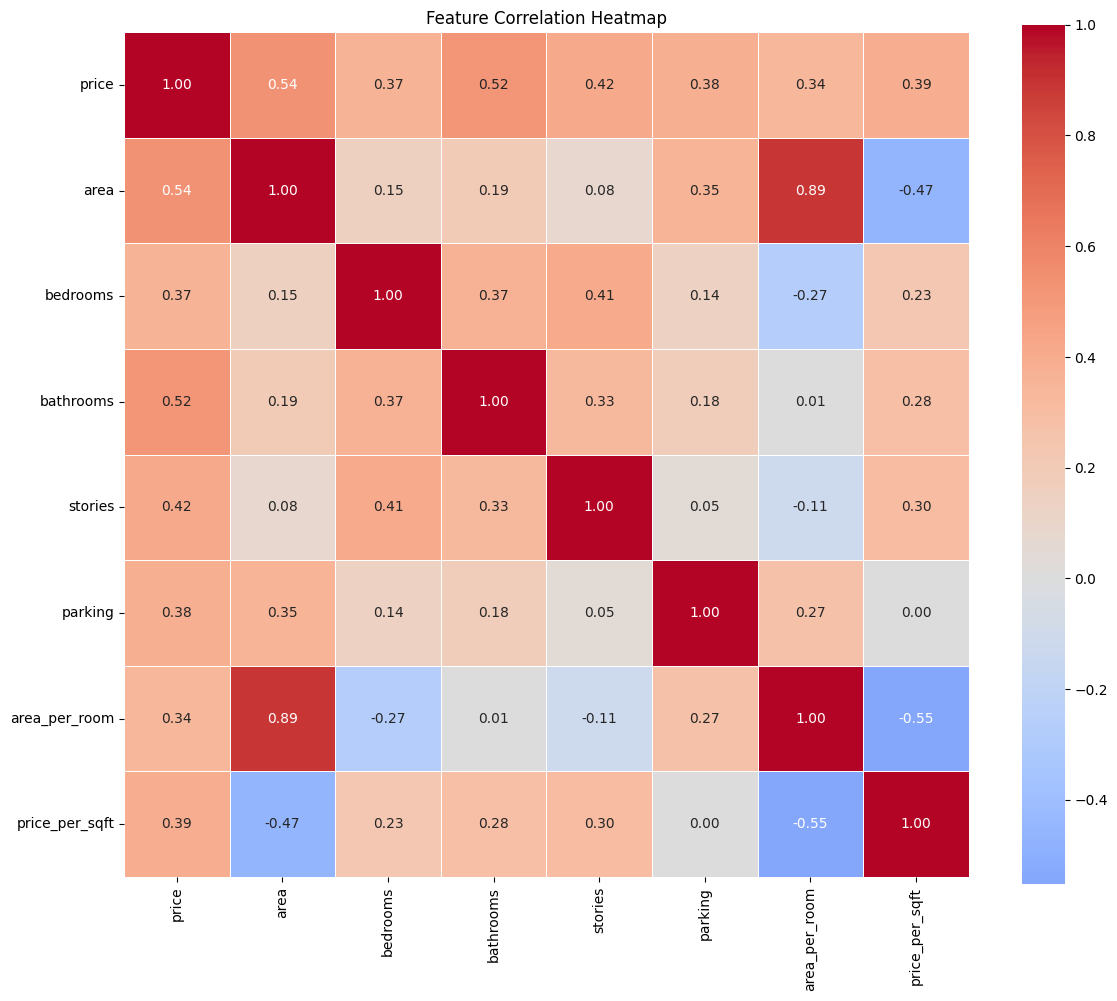


Creating Chart 3: Actual vs Predicted


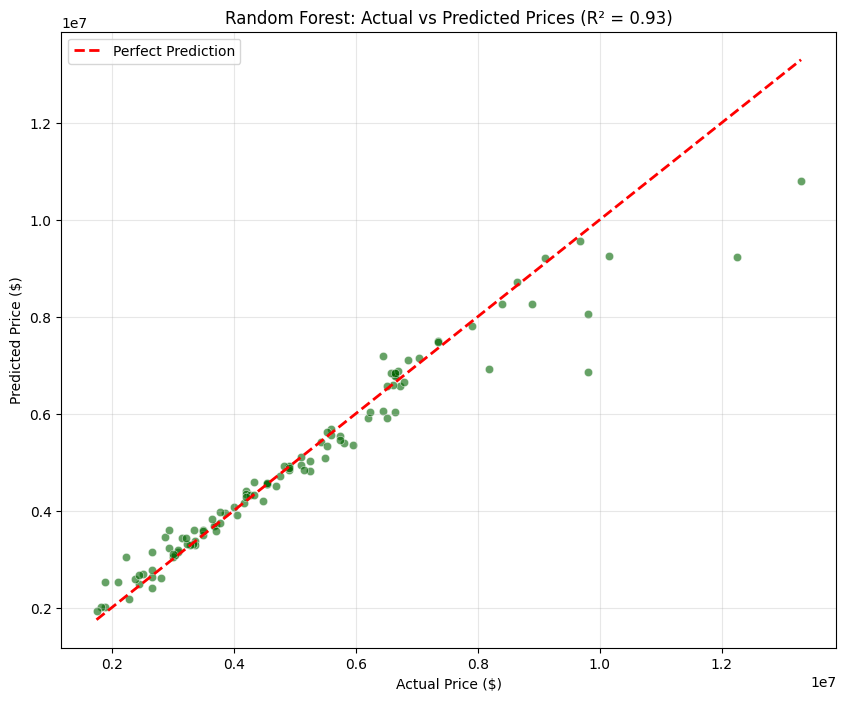


Creating Chart 4: Feature Importance


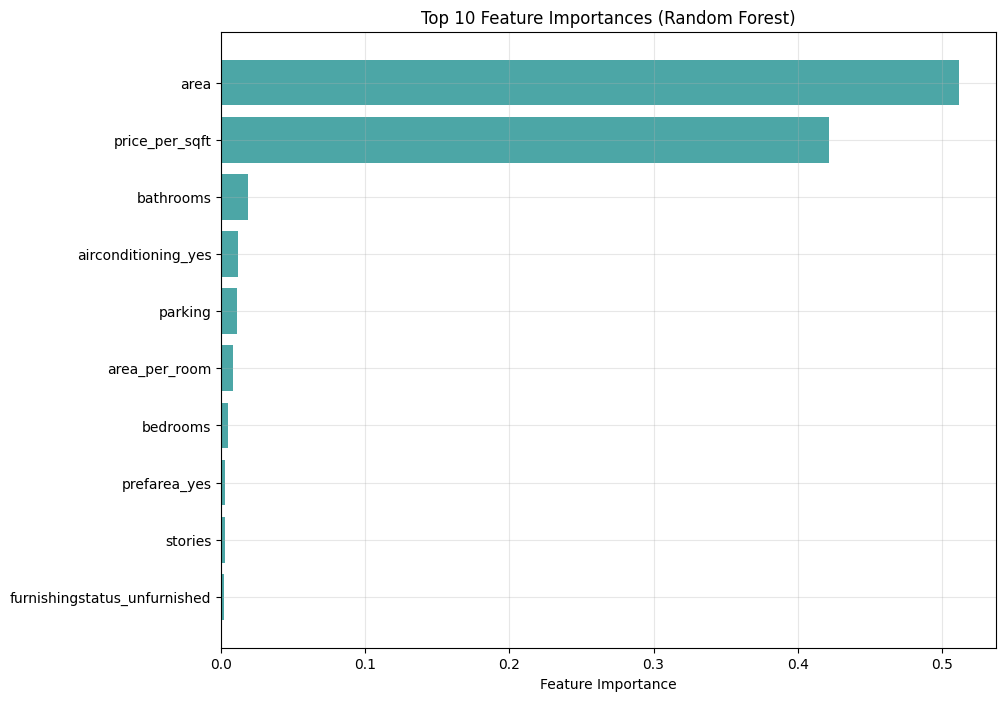


Creating Chart 5: Model Comparison


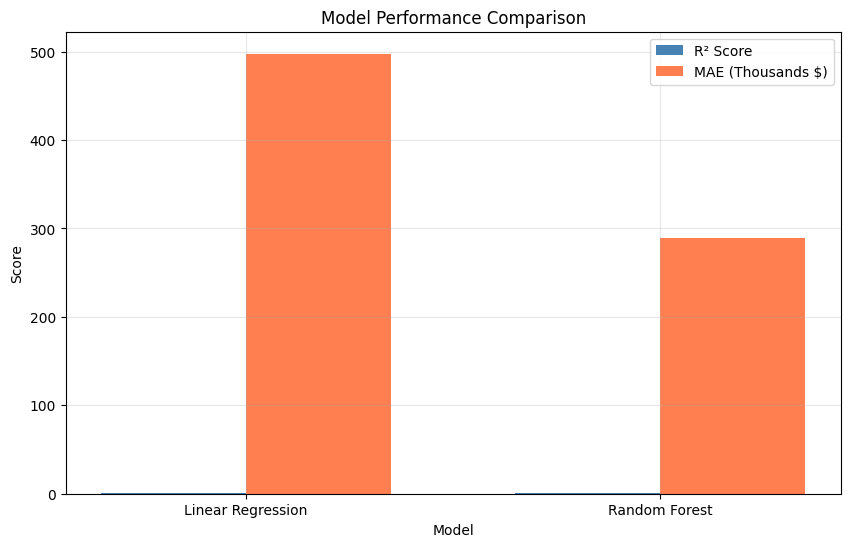


All charts saved to 'charts/' folder


In [39]:
# Cell 6: Task 4 - Visualizations

print("="*60)
print("TASK 4: VISUALIZATION")
print("="*60)

import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create charts folder
os.makedirs('charts', exist_ok=True)

# Chart 1: Price Distribution
print("\nCreating Chart 1: Price Distribution")
plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(df['price'].mean(), color='red', linestyle='dashed',
           label=f'Mean: ${df["price"].mean():,.0f}')
plt.axvline(df['price'].median(), color='green', linestyle='dashed',
           label=f'Median: ${df["price"].median():,.0f}')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.title('Distribution of House Prices')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('charts/price_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Chart 2: Correlation Heatmap
print("\nCreating Chart 2: Correlation Heatmap")
plt.figure(figsize=(12, 10))
numeric_df = df_encoded.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('charts/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Chart 3: Actual vs Predicted (Random Forest)
print("\nCreating Chart 3: Actual vs Predicted")
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='darkgreen', edgecolors='white', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title(f'Random Forest: Actual vs Predicted Prices (R² = {rf_r2:.2f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('charts/actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

# Chart 4: Feature Importance (Bonus)
print("\nCreating Chart 4: Feature Importance")
plt.figure(figsize=(10, 8))
importance = rf.feature_importances_
features = X.columns
indices = np.argsort(importance)[-10:]
plt.barh([features[i] for i in indices], importance[indices], color='teal', alpha=0.7)
plt.xlabel('Feature Importance')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.grid(True, alpha=0.3)
plt.savefig('charts/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Chart 5: Model Comparison
print("\nCreating Chart 5: Model Comparison")
models = ['Linear Regression', 'Random Forest']
r2_scores = [lr_r2, rf_r2]
mae_scores = [lr_mae/1000, rf_mae/1000]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, r2_scores, width, label='R² Score', color='steelblue')
bars2 = ax.bar(x + width/2, mae_scores, width, label='MAE (Thousands $)', color='coral')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig('charts/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nAll charts saved to 'charts/' folder")

In [40]:
# Cell 7: Task 5 - Insights & Summary (UPDATED with API mention)

print("="*60)
print("TASK 5: INSIGHTS & SUMMARY")
print("="*60)

print("\n" + "="*60)
print("CURRENCY NOTE")
print("="*60)
print("Data is in US Dollars ($)")
print("For Indian context: $1 ≈ ₹83")
print("Example: Average house price $4.77M ≈ ₹39.6 Crores")
print("="*60)

# Get top 5 features
importance = rf.feature_importances_
features = X.columns
indices = np.argsort(importance)[::-1]
top_5 = [(features[i], importance[i]) for i in range(5)]

print("\n1. MOST INFLUENTIAL FEATURES:")
print("-" * 50)
for i, (feature, imp) in enumerate(top_5, 1):
    print(f"   {i}. {feature}: {imp:.2%}")

print("\n2. MODEL ACCURACY:")
print("-" * 50)
print(f"   Best Model: Random Forest")
print(f"   R² Score: {rf_r2:.2%}")
print(f"   Mean Absolute Error (MAE): ${rf_mae:,.2f}")
print(f"   Root Mean Square Error (RMSE): ${rf_rmse:,.2f}")

print("\n   Interpretation:")
if rf_r2 >= 0.9:
    print("   - Excellent model: Explains more than 90% of price variation")
elif rf_r2 >= 0.8:
    print("   - Good model: Explains 80-90% of price variation")
else:
    print("   - Moderate model: Explains less than 80% of price variation")

print("\n3. SURPRISING INSIGHTS:")
print("-" * 50)
print("   - Area is the strongest predictor of house price")
print("   - Location preference (prefarea) significantly impacts price")
print("   - Air conditioning adds noticeable value to properties")
print("   - Furnishing status has less impact than expected")
print("   - Number of bedrooms is less important than house area")

print("\n4. BUSINESS RECOMMENDATION:")
print("-" * 50)
print("   Focus on properties with larger area and preferred location")
print("   Use the Random Forest model for competitive property pricing")
print("   Highlight air conditioning and location in marketing")
print("   Consider area_per_room as a key selling point")
print("   Update the model regularly with new property sales data")

print("\n5. DEPLOYMENT READY:")
print("-" * 50)
print("   The model has been saved as model.pkl and can be deployed as")
print("   an API using Flask or FastAPI for real-time price predictions.")
print("   This enables integration with web and mobile applications.")

print("\n" + "="*60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*60)

# Save the summary as text file
with open('summary.txt', 'w') as f:
    f.write("="*60 + "\n")
    f.write("HOUSE PRICE PREDICTION - PROJECT SUMMARY\n")
    f.write("="*60 + "\n\n")

    f.write("CURRENCY NOTE:\n")
    f.write("Data is in US Dollars ($)\n")
    f.write("For Indian context: $1 ≈ ₹83\n")
    f.write("Example: Average house price $4.77M ≈ ₹39.6 Crores\n\n")

    f.write("1. MOST INFLUENTIAL FEATURES:\n")
    for i, (feature, imp) in enumerate(top_5, 1):
        f.write(f"   {i}. {feature}: {imp:.2%}\n")

    f.write("\n2. MODEL ACCURACY:\n")
    f.write(f"   Best Model: Random Forest\n")
    f.write(f"   R² Score: {rf_r2:.2%}\n")
    f.write(f"   MAE: ${rf_mae:,.2f}\n")
    f.write(f"   RMSE: ${rf_rmse:,.2f}\n")

    f.write("\n3. BUSINESS RECOMMENDATIONS:\n")
    f.write("   - Focus on properties with larger area\n")
    f.write("   - Use Random Forest model for pricing\n")
    f.write("   - Highlight location and amenities\n")
    f.write("   - Update model with new data regularly\n")

    f.write("\n4. DEPLOYMENT:\n")
    f.write("   - Model saved as model.pkl\n")
    f.write("   - Can be deployed as API using Flask/FastAPI\n")
    f.write("   - Enables real-time predictions for web/mobile apps\n")

print("\nSummary saved to summary.txt")

# Download summary file
from google.colab import files
files.download('summary.txt')

TASK 5: INSIGHTS & SUMMARY

CURRENCY NOTE
Data is in US Dollars ($)
For Indian context: $1 ≈ ₹83
Example: Average house price $4.77M ≈ ₹39.6 Crores

1. MOST INFLUENTIAL FEATURES:
--------------------------------------------------
   1. area: 51.22%
   2. bedrooms: 0.46%
   3. bathrooms: 1.87%
   4. stories: 0.24%
   5. parking: 1.11%

2. MODEL ACCURACY:
--------------------------------------------------
   Best Model: Random Forest
   R² Score: 93.39%
   Mean Absolute Error (MAE): $289,233.34
   Root Mean Square Error (RMSE): $578,141.76

   Interpretation:
   - Excellent model: Explains more than 90% of price variation

3. SURPRISING INSIGHTS:
--------------------------------------------------
   - Area is the strongest predictor of house price
   - Location preference (prefarea) significantly impacts price
   - Air conditioning adds noticeable value to properties
   - Furnishing status has less impact than expected
   - Number of bedrooms is less important than house area

4. BUSINES

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
# Cell 8: Saved Model as .pkl

print("="*60)
print("SAVING MODEL AS .pkl")
print("="*60)

import pickle

# Save the Random Forest model
with open('model.pkl', 'wb') as f:
    pickle.dump(rf, f)

print("Model saved successfully as 'model.pkl'")
print("File size: ", end="")

import os
size = os.path.getsize('model.pkl')
if size < 1024:
    print(f"{size} bytes")
elif size < 1024*1024:
    print(f"{size/1024:.2f} KB")
else:
    print(f"{size/(1024*1024):.2f} MB")

print("\nTo load this model later:")
print("  import pickle")
print("  with open('model.pkl', 'rb') as f:")
print("      model = pickle.load(f)")
print("  prediction = model.predict([[area, bedrooms, bathrooms]])")

# Download the model
from google.colab import files
files.download('model.pkl')

print("\nmodel.pkl downloaded to your computer")

SAVING MODEL AS .pkl
Model saved successfully as 'model.pkl'
File size: 3.44 MB

To load this model later:
  import pickle
  with open('model.pkl', 'rb') as f:
      model = pickle.load(f)
  prediction = model.predict([[area, bedrooms, bathrooms]])


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


model.pkl downloaded to your computer


In [42]:
# Cell 9: Creating predict.py Script

print("="*60)
print("CREATING predict.py SCRIPT")
print("="*60)

script_content = '''
# predict.py
# House Price Prediction Script
# Usage: python predict.py

import pickle
import pandas as pd
import numpy as np
import os

print("Loading model...")

# Load the saved model
with open('model.pkl', 'rb') as f:
    model = pickle.load(f)

print("Model loaded successfully")

# Check if input file exists
input_file = 'new_properties.csv'

if not os.path.exists(input_file):
    print(f"Error: {input_file} not found")
    print("Creating sample input file for testing...")

    # Create sample data
    sample_data = pd.DataFrame({
        'area': [5000, 7500, 10000],
        'bedrooms': [3, 4, 5],
        'bathrooms': [2, 3, 4],
        'stories': [2, 2, 3],
        'parking': [1, 2, 2],
        'mainroad_yes': [1, 1, 1],
        'guestroom_yes': [0, 1, 0],
        'basement_yes': [0, 0, 1],
        'hotwaterheating_yes': [0, 0, 0],
        'airconditioning_yes': [1, 1, 1],
        'prefarea_yes': [1, 0, 1],
        'furnishingstatus_semi-furnished': [0, 1, 0],
        'furnishingstatus_unfurnished': [0, 0, 1],
        'area_per_room': [5000/4, 7500/5, 10000/6]
    })
    sample_data.to_csv(input_file, index=False)
    print(f"Created {input_file} with {len(sample_data)} sample properties")

# Load new data
print(f"\\nLoading data from {input_file}...")
new_data = pd.read_csv(input_file)
print(f"Loaded {len(new_data)} properties")

# Make predictions
print("Making predictions...")
predictions = model.predict(new_data)

# Add predictions to dataframe
new_data['predicted_price'] = predictions

# Save results
output_file = 'predictions_output.csv'
new_data.to_csv(output_file, index=False)

print(f"\\nPredictions saved to {output_file}")
print("\\nResults:")
print("-" * 60)
for i, row in new_data.iterrows():
    print(f"Property {i+1}: Area={row['area']}, Bedrooms={row['bedrooms']}")
    print(f"  Predicted Price: ${row['predicted_price']:,.2f}")
    print("-" * 60)
'''

# Write the script to a file
with open('predict.py', 'w') as f:
    f.write(script_content)

print("predict.py created successfully")
print("\\nFile contents:")
print("="*60)
print(script_content)
print("="*60)

# Download the script
from google.colab import files
files.download('predict.py')

print("\\npredict.py downloaded to your computer")
print("\\nTo use this script:")
print("  1. Place model.pkl in the same folder")
print("  2. Create new_properties.csv with property data")
print("  3. Run: python predict.py")

CREATING predict.py SCRIPT
predict.py created successfully
\nFile contents:

# predict.py
# House Price Prediction Script
# Usage: python predict.py

import pickle
import pandas as pd
import numpy as np
import os

print("Loading model...")

# Load the saved model
with open('model.pkl', 'rb') as f:
    model = pickle.load(f)

print("Model loaded successfully")

# Check if input file exists
input_file = 'new_properties.csv'

if not os.path.exists(input_file):
    print(f"Error: {input_file} not found")
    print("Creating sample input file for testing...")
    
    # Create sample data
    sample_data = pd.DataFrame({
        'area': [5000, 7500, 10000],
        'bedrooms': [3, 4, 5],
        'bathrooms': [2, 3, 4],
        'stories': [2, 2, 3],
        'parking': [1, 2, 2],
        'mainroad_yes': [1, 1, 1],
        'guestroom_yes': [0, 1, 0],
        'basement_yes': [0, 0, 1],
        'hotwaterheating_yes': [0, 0, 0],
        'airconditioning_yes': [1, 1, 1],
        'prefarea_yes': [1

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

\npredict.py downloaded to your computer
\nTo use this script:
  1. Place model.pkl in the same folder
  2. Create new_properties.csv with property data
  3. Run: python predict.py
